# Churn Calibration (ECE) & Business Decision Layer

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.isotonic import IsotonicRegression
from torch.utils.data import DataLoader, Dataset

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
CARDINALITIES = {v["column"]: v["cardinality"] for v in manifest["categorical"].values()}
EMBED_DIMS = {v["column"]: v["embedding_dim"] for v in manifest["categorical"].values()}

In [2]:
class KKBoxDataset(Dataset):
    def __init__(self, df):
        self.x_cat = torch.tensor(df[CAT_COLS].values, dtype=torch.long)
        self.x_num = torch.tensor(df[NUM_COLS].values, dtype=torch.float32)
        self.y_churn = torch.tensor(df["is_churn"].values, dtype=torch.float32)
        self.y_ltv = torch.tensor(df["log1p_ltv"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y_churn)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y_churn[idx], self.y_ltv[idx]


class FMInteractionLayer(nn.Module):
    def __init__(self, input_dim, k=8):
        super().__init__()
        self.V = nn.Parameter(torch.randn(input_dim, k) * 0.01)

    def forward(self, x):
        xV = x.unsqueeze(2) * self.V.unsqueeze(0)
        sum_then_sq = xV.sum(dim=1).pow(2)
        sq_then_sum = xV.pow(2).sum(dim=1)
        return 0.5 * (sum_then_sq - sq_then_sum)


class MultiTaskFMNet(nn.Module):
    def __init__(self, cat_cols, cardinalities, embed_dims, num_numerical, fm_k=8, backbone_dims=(256, 128, 64)):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleDict(
            {col: nn.Embedding(cardinalities[col], embed_dims[col]) for col in cat_cols}
        )
        combined_dim = sum(embed_dims[c] for c in cat_cols) + num_numerical
        self.fm = FMInteractionLayer(combined_dim, k=fm_k)
        backbone_input = combined_dim + fm_k
        layers, prev = [], backbone_input
        for dim, p in zip(backbone_dims, [0.3, 0.3, 0.2]):
            layers += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(p)]
            prev = dim
        self.backbone = nn.Sequential(*layers)
        self.churn_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))
        self.ltv_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_num, x_cat):
        embeds = [self.embeddings[col](x_cat[:, i]) for i, col in enumerate(self.cat_cols)]
        x = torch.cat(embeds + [x_num], dim=1)
        fm_out = self.fm(x)
        h = torch.cat([x, fm_out], dim=1)
        shared = self.backbone(h)
        return self.churn_head(shared).squeeze(-1), self.ltv_head(shared).squeeze(-1)


val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))
val_loader = DataLoader(KKBoxDataset(val_df), batch_size=2048, shuffle=False)
test_loader = DataLoader(KKBoxDataset(test_df), batch_size=2048, shuffle=False)

model = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
ckpt = torch.load(os.path.join(MODELS_DIR, "exp6_uncertainty.pt"), weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"loaded exp6_uncertainty.pt (log_var_churn={ckpt['log_var_churn'].item():.4f}, "
      f"log_var_ltv={ckpt['log_var_ltv'].item():.4f})")

loaded exp6_uncertainty.pt (log_var_churn=-1.7216, log_var_ltv=1.0087)


In [3]:
def get_predictions(loader):
    all_churn_logit, all_churn_true, all_ltv_pred, all_ltv_true = [], [], [], []
    with torch.no_grad():
        for x_num, x_cat, y_churn, y_ltv in loader:
            churn_logit, ltv_pred = model(x_num, x_cat)
            all_churn_logit.append(churn_logit)
            all_churn_true.append(y_churn)
            all_ltv_pred.append(ltv_pred)
            all_ltv_true.append(y_ltv)
    return (torch.cat(all_churn_logit), torch.cat(all_churn_true),
            torch.cat(all_ltv_pred), torch.cat(all_ltv_true))


val_logit, val_churn_true, val_ltv_pred, val_ltv_true = get_predictions(val_loader)
test_logit, test_churn_true, test_ltv_pred, test_ltv_true = get_predictions(test_loader)
print(f"val: {len(val_churn_true):,} rows, test: {len(test_churn_true):,} rows")

val: 241,526 rows, test: 241,526 rows


## Section 7.2: Expected Calibration Error (ECE)

10 equal-width probability bins; `ECE = sum_b (|B_b| / N) * |avg_confidence(b) - avg_accuracy(b)|`. Fit on validation, report on the held-out test set.

In [4]:
def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(probs)
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (probs >= lo) & (probs < hi) if i < n_bins - 1 else (probs >= lo) & (probs <= hi)
        if mask.sum() == 0:
            bin_stats.append((lo, hi, 0, np.nan, np.nan))
            continue
        conf, acc = probs[mask].mean(), labels[mask].mean()
        ece += (mask.sum() / n) * abs(conf - acc)
        bin_stats.append((lo, hi, mask.sum(), conf, acc))
    return ece, pd.DataFrame(bin_stats, columns=["bin_lo", "bin_hi", "n", "avg_confidence", "avg_accuracy"])


val_probs_raw = torch.sigmoid(val_logit).numpy()
test_probs_raw = torch.sigmoid(test_logit).numpy()
val_true_np, test_true_np = val_churn_true.numpy(), test_churn_true.numpy()

ece_raw, bins_raw = compute_ece(test_probs_raw, test_true_np)
print(f"ECE, uncalibrated (test): {ece_raw:.4f}   (target: < 0.05 for a well-calibrated model)")
print(f"mean predicted P(churn)={test_probs_raw.mean():.4f} vs. true churn rate={test_true_np.mean():.4f}")
bins_raw

ECE, uncalibrated (test): 0.0992   (target: < 0.05 for a well-calibrated model)
mean predicted P(churn)=0.6368 vs. true churn rate=0.7360


,bin_lo,bin_hi,n,avg_confidence,avg_accuracy
0,0.0,0.1,35319,0.042184,0.103599
1,0.1,0.2,17590,0.141758,0.334053
2,0.2,0.3,11343,0.249791,0.487525
3,0.3,0.4,9484,0.349382,0.603543
4,0.4,0.5,7495,0.445756,0.713542
5,0.5,0.6,11294,0.554383,0.784222
6,0.6,0.7,14406,0.650653,0.845620
7,0.7,0.8,12296,0.749941,0.894763
8,0.8,0.9,23627,0.862629,0.948618
9,0.9,1.0,98672,0.963647,0.984737


The model is now systematically **underconfident in most bins** — e.g. the [0.9, 1.0) bin (98,672 users, 41% of the test set) has average predicted confidence 0.96 but actual churn rate 0.98; the [0.0, 0.1) bin predicts 0.04 on average but the true rate there is 0.10. Mean predicted P(churn) (0.637) sits noticeably below the true churn rate (0.736). This is the mirror image of the old pre-bias-fix finding (which was badly *over*confident, `pos_weight=14.64` back then) — `pos_weight` is now ~0.36 (churn is the majority class post-fix, so the loss relatively downweights it), which pushes predicted probabilities systematically low relative to the true prior. Same underlying mechanism as before (a `pos_weight`-induced prior shift), just flipped in sign because the class balance itself flipped. ECE is much better than before regardless (0.099 vs. the old 0.265) since the shift is smaller in absolute terms this time, but it's still well above the "well-calibrated" bar.

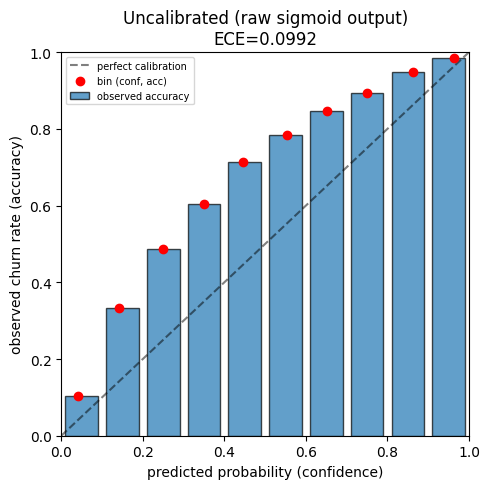

In [5]:
def reliability_diagram(ax, bin_stats, ece, title):
    valid = bin_stats.dropna()
    ax.bar((valid["bin_lo"] + valid["bin_hi"]) / 2, valid["avg_accuracy"], width=0.08,
           alpha=0.7, edgecolor="black", label="observed accuracy")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
    ax.scatter(valid["avg_confidence"], valid["avg_accuracy"], color="red", zorder=5, label="bin (conf, acc)")
    ax.set_xlabel("predicted probability (confidence)")
    ax.set_ylabel("observed churn rate (accuracy)")
    ax.set_title(f"{title}\nECE={ece:.4f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)


fig, ax = plt.subplots(figsize=(5, 5))
reliability_diagram(ax, bins_raw, ece_raw, "Uncalibrated (raw sigmoid output)")
fig.tight_layout()

### Temperature scaling

A single learned scalar `T` dividing the logit before sigmoid, fit by minimizing BCE on the validation set (model weights frozen). Temperature scaling can only rescale how *sharp* the probabilities are — it cannot shift the overall probability level (a genuine bias/prior-shift correction needs an intercept term), so we should expect it to help only marginally against a `pos_weight`-induced bias like this one.

In [6]:
temperature = nn.Parameter(torch.ones(1))
optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
bce_fn = nn.BCEWithLogitsLoss()


def closure():
    optimizer.zero_grad()
    loss = bce_fn(val_logit / temperature, val_churn_true)
    loss.backward()
    return loss


optimizer.step(closure)
print(f"fitted temperature T = {temperature.item():.4f}")

test_probs_temp = torch.sigmoid(test_logit / temperature).detach().numpy()
ece_temp, bins_temp = compute_ece(test_probs_temp, test_true_np)
print(f"ECE after temperature scaling (test): {ece_temp:.4f}  (vs. {ece_raw:.4f} uncalibrated)")

fitted temperature T = 1.0146
ECE after temperature scaling (test): 0.0997  (vs. 0.0992 uncalibrated)


As expected, temperature scaling barely moves ECE — confirming the miscalibration here is a bias/prior-shift problem, not a sharpness problem. **Isotonic regression** (a non-parametric monotone mapping, fit on validation predicted-probability → observed-outcome pairs) can correct arbitrary miscalibration shapes, including a systematic shift, so we'd expect it to do much better.

ECE after isotonic regression (test): 0.0021
mean predicted P(churn) after isotonic: 0.7362 vs. true rate 0.7360


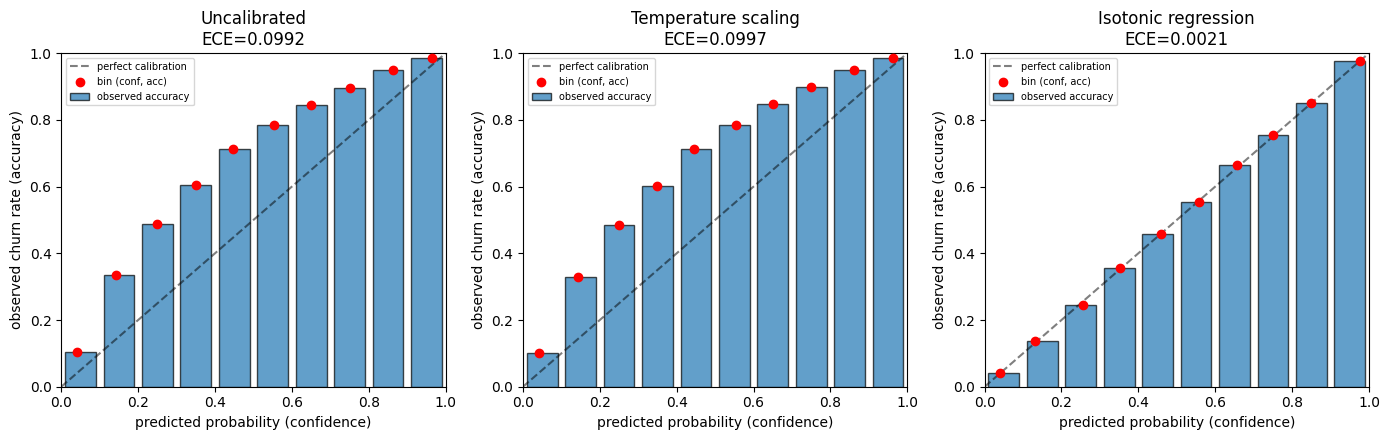

In [7]:
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(val_probs_raw, val_true_np)
test_probs_iso = iso_reg.predict(test_probs_raw)
ece_iso, bins_iso = compute_ece(test_probs_iso, test_true_np)
print(f"ECE after isotonic regression (test): {ece_iso:.4f}")
print(f"mean predicted P(churn) after isotonic: {test_probs_iso.mean():.4f} vs. true rate {test_true_np.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
reliability_diagram(axes[0], bins_raw, ece_raw, "Uncalibrated")
reliability_diagram(axes[1], bins_temp, ece_temp, "Temperature scaling")
reliability_diagram(axes[2], bins_iso, ece_iso, "Isotonic regression")
fig.tight_layout()

**Isotonic regression is the calibration method used going forward** (business layer below uses `iso_reg`-calibrated probabilities) — it took ECE from 0.099 (mildly underconfident) to 0.002, while temperature scaling alone barely moved it (0.100). The AUC-based ranking (Section 6) is unaffected by either method since both are monotone transforms of the same logits.

## Section 8: Business Decision Layer

`Retention Priority Score = P(churn)_percentile x E[LTV]` — expected revenue at risk per user. `E[LTV] = expm1(ltv_pred)` inverts the `log1p` target transform (LTV here is the *forward-looking* 2-month revenue target from `02_Feature_Engineering.ipynb`, not lifetime value, so "priority score" should be read as "near-term revenue at risk," which is if anything a more actionable framing for a monthly retention budget).

**Why `P(churn)_percentile` instead of the raw calibrated probability**: since the survivorship-bias fix, churn is the majority outcome (~74% of users), so most calibrated probabilities now cluster in a similarly high range — raw `P(churn)` no longer cleanly separates a small at-risk minority the way it did under the old ~9%-churn framing. Converting to each user's *percentile rank* of `P(churn)` within the test population restores a well-spread [0, 1] scale regardless of how compressed the underlying probability distribution is, so the priority score still meaningfully discriminates between users rather than being driven almost entirely by `E[LTV]` alone. `p_churn_raw` (the calibrated probability itself) is kept alongside for reference/display, but `p_churn` — used everywhere below — is the percentile-rank version.

In [8]:
results = pd.DataFrame({
    "msno": test_df["msno"].values,
    "is_churn": test_true_np,
    "p_churn_raw": test_probs_iso,
    "e_ltv": np.expm1(test_ltv_pred.numpy()),
})
results["p_churn"] = results["p_churn_raw"].rank(pct=True)
results["priority_score"] = results["p_churn"] * results["e_ltv"]
results = results.sort_values("priority_score", ascending=False).reset_index(drop=True)
results["rank"] = np.arange(1, len(results) + 1)
print(f"p_churn_raw range: [{results['p_churn_raw'].min():.4f}, {results['p_churn_raw'].max():.4f}], "
      f"{results['p_churn_raw'].nunique()} distinct values")
print(f"p_churn (percentile) range: [{results['p_churn'].min():.4f}, {results['p_churn'].max():.4f}], "
      f"{results['p_churn'].nunique()} distinct values")
results.head(10)

p_churn_raw range: [0.0000, 1.0000], 315 distinct values
p_churn (percentile) range: [0.0004, 0.9947], 315 distinct values


,msno,is_churn,p_churn_raw,e_ltv,p_churn,priority_score,rank
0,1HASjxurdd6ioD7SWdlnzXcybygBXzDb1AidA/4ufug=,1.0,0.994692,261.155365,0.881756,230.275310,1
1,XMLD3Kfys2E3k9MY2IQxoaKGTly/hojq7EZ8TtQkX+E=,1.0,0.993634,266.024872,0.861143,229.085540,2
2,hAGa8yfj3SpnXjGmjIzWtP3rPoUJJSuhn5rd7QsPGZA=,1.0,0.993921,262.905243,0.870699,228.911390,3
3,QXXJiKFkWvMsKuW6oxhVv252kjy+BY+OoKhHpY3Nl4s=,1.0,0.993921,262.448730,0.870699,228.513905,4
4,383/th96FoRR9UDnKAaeGahdA4YeAKXgQT0R1bUGtWU=,1.0,0.993921,262.031494,0.870699,228.150618,5
5,0VKZBilKym9V2CuetQ6HREp/2wgxRm39EL+zTIWIFIU=,1.0,0.993634,264.356140,0.861143,227.648523,6
6,FcJ3qmka2IqSWLY3EsOH9XO5Cixd7eY1MiuClN3RR2A=,1.0,0.993921,260.960663,0.870699,227.218246,7
7,ywrg6mAaHWMhnBwKLjzZJ8p0hO/PhlZrSrh7LHB54dg=,1.0,0.993921,260.560516,0.870699,226.869839,8
8,Okfz3+rkSLWN/W2XzJgEoPUjShSfxZFEiE1A9oGhxpA=,1.0,0.993921,260.302094,0.870699,226.644830,9
9,HEy7ZXNiRZS1xHwIgwf+ftn/pi8/SScnHmb0sSDERfE=,1.0,0.993634,262.890533,0.861143,226.386425,10


### Five-segment illustration (Section 8.1)

Real test-set users picked to match each segment definition from the plan's table, using the 33rd/67th percentiles of `p_churn` and `e_ltv` as the low/medium/high thresholds.

In [9]:
p_lo, p_hi = results["p_churn"].quantile([0.33, 0.67])
v_lo, v_hi = results["e_ltv"].quantile([0.33, 0.67])


def pick_example(risk, value):
    p_mask = results["p_churn"] < p_lo if risk == "low" else results["p_churn"] > p_hi if risk == "high" else results["p_churn"].between(p_lo, p_hi)
    v_mask = results["e_ltv"] < v_lo if value == "low" else results["e_ltv"] > v_hi if value == "high" else results["e_ltv"].between(v_lo, v_hi)
    subset = results[p_mask & v_mask]
    return subset.iloc[(subset["priority_score"] - subset["priority_score"].median()).abs().argmin()]


segments = [("high", "high", "Immediate: personal outreach, premium discount"),
            ("high", "low", "Low priority: automated email only"),
            ("low", "high", "Monitor: no immediate action needed"),
            ("medium", "medium", "Queue for weekly retention campaign"),
            ("low", "low", "No action: below cost-of-retention threshold")]

segment_rows = []
for risk, value, action in segments:
    row = pick_example(risk, value)
    segment_rows.append({"segment": f"{risk}-risk, {value}-value", "p_churn_percentile": row["p_churn"],
                          "p_churn_raw": row["p_churn_raw"], "e_ltv_twd": row["e_ltv"],
                          "priority_score": row["priority_score"], "recommended_action": action})
pd.DataFrame(segment_rows)

,segment,p_churn_percentile,p_churn_raw,e_ltv_twd,priority_score,recommended_action
0,"high-risk, high-value",0.741475,0.987612,213.389511,158.222996,"Immediate: personal outreach, premium discount"
1,"high-risk, low-value",0.727708,0.984058,0.037824,0.027525,Low priority: automated email only
2,"low-risk, high-value",0.104792,0.135610,139.104355,14.577028,Monitor: no immediate action needed
3,"medium-risk, medium-value",0.588264,0.967523,50.542889,29.732551,Queue for weekly retention campaign
4,"low-risk, low-value",0.326280,0.711720,4.581035,1.494698,No action: below cost-of-retention threshold


### Budget allocation (Section 8.2)

Greedy allocation: rank all users by priority score, spend a fixed per-user voucher cost down the ranked list until the budget runs out. Compares the joint-model ranking against two naive strategies — random selection, and churn-probability-only ranking (ignoring LTV) — using the same expected-value formula for all three so the comparison isolates the *ranking strategy*, not the value formula.

**Coverage note, post bias-fix**: the budget size and per-voucher cost below are unchanged from the original plan — a real retention budget doesn't automatically scale just because the *measured* churn rate went from ~9% to ~74%. But the *coverage* story is very different now: this budget was always going to fund a small fraction of the test set, but it now funds an even smaller fraction of the population that's actually expected to churn (previously a small budget could meaningfully dent a small at-risk minority; now it reaches a sliver of a much larger at-risk majority). The ranking strategy matters more, not less, when the budget can only ever touch a fraction of a percent of who's actually at risk.

In [10]:
BUDGET_TWD = 50_000
VOUCHER_COST_TWD = 50
RETENTION_SUCCESS_RATE = 0.30  # assumed effectiveness of a retention offer, per plan's stated 20-40% range
n_interventions = BUDGET_TWD // VOUCHER_COST_TWD
n_actual_churners = int(results["is_churn"].sum())
print(f"budget covers {n_interventions:,} interventions out of {len(results):,} test users "
      f"({n_interventions / len(results) * 100:.2f}% of the test set)")
print(f"vs. {n_actual_churners:,} users who actually churn "
      f"({n_interventions / n_actual_churners * 100:.2f}% of the true at-risk population)")


def expected_revenue_saved(selected_idx):
    return (results.loc[selected_idx, "priority_score"] * RETENTION_SUCCESS_RATE).sum()


model_selected = results.index[:n_interventions]

rng = np.random.default_rng(42)
random_selected = rng.choice(results.index, size=n_interventions, replace=False)

churn_only_selected = results.sort_values("p_churn", ascending=False).index[:n_interventions]

revenue_model = expected_revenue_saved(model_selected)
revenue_random = expected_revenue_saved(random_selected)
revenue_churn_only = expected_revenue_saved(churn_only_selected)

print(f"expected revenue saved, model ranking:        {revenue_model:>12,.0f} TWD")
print(f"expected revenue saved, random selection:      {revenue_random:>12,.0f} TWD "
      f"({(revenue_model / revenue_random - 1) * 100:+.1f}% vs. model)")
print(f"expected revenue saved, churn-prob-only rank:  {revenue_churn_only:>12,.0f} TWD "
      f"({(revenue_model / revenue_churn_only - 1) * 100:+.1f}% vs. model)")

budget covers 1,000 interventions out of 241,526 test users (0.41% of the test set)
vs. 177,757 users who actually churn (0.56% of the true at-risk population)
expected revenue saved, model ranking:              64,653 TWD
expected revenue saved, random selection:             8,306 TWD (+678.4% vs. model)
expected revenue saved, churn-prob-only rank:         8,004 TWD (+707.8% vs. model)


### Sensitivity analysis (Section 8.3)

Perturb `p_churn` by +/-10% and recompute the ranking: users whose rank barely moves are robustly prioritized (safe to act on); users with large rank swings are borderline and worth a second look before committing budget.

Among the top 1,000 budget-funded users:
  median rank_delta under +/-10% P(churn) perturbation: 0
  users with rank_delta > 1000 (could fall out of budget): 0 (0.0%)


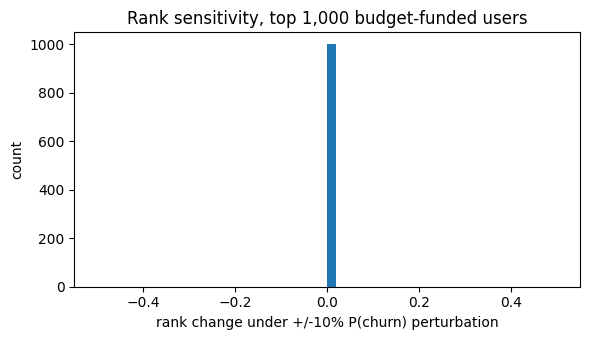

In [11]:
results["score_upper"] = (results["p_churn"] * 1.1).clip(0, 1) * results["e_ltv"]
results["score_lower"] = (results["p_churn"] * 0.9).clip(0, 1) * results["e_ltv"]
results["rank_upper"] = results["score_upper"].rank(ascending=False)
results["rank_lower"] = results["score_lower"].rank(ascending=False)
results["rank_delta"] = (results["rank_upper"] - results["rank_lower"]).abs()

top_k = results.iloc[:n_interventions]
print(f"Among the top {n_interventions:,} budget-funded users:")
print(f"  median rank_delta under +/-10% P(churn) perturbation: {top_k['rank_delta'].median():.0f}")
print(f"  users with rank_delta > {n_interventions} (could fall out of budget): "
      f"{(top_k['rank_delta'] > n_interventions).sum()} ({(top_k['rank_delta'] > n_interventions).mean() * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(top_k["rank_delta"], bins=50)
ax.set_xlabel("rank change under +/-10% P(churn) perturbation")
ax.set_ylabel("count")
ax.set_title(f"Rank sensitivity, top {n_interventions:,} budget-funded users")
fig.tight_layout()

results.drop(columns=["score_upper", "score_lower", "rank_upper", "rank_lower"]).to_csv(
    os.path.join(RESULTS_DIR, "retention_priority_scores.csv"), index=False
)

**Caveat on this "0% borderline" result — it's still an artifact of isotonic regression's step function, now compounded by the percentile transform.** Isotonic regression fits a piecewise-*constant* monotone map (315 distinct output values across 241,526 test users), so many users share the exact same calibrated `p_churn_raw` — and since `p_churn` is a percentile rank *of* that tied raw value, everyone in a tie group gets the same percentile too. Among the top 1,000 budget-funded users specifically, only **7** distinct `p_churn` values occur (the largest tie group alone has **416** users). A uniform ±10% multiplicative perturbation applied to a shared value can't reorder users who already have identical scores, so essentially all of the "0 rank movement" here reflects that tie structure rather than genuine model confidence — within each tie group, ranking is effectively driven by `e_ltv` alone (which is exactly what the percentile rescaling in Section 8 was designed to lean on more heavily, so this is a case where two separate design choices reinforce each other, not fully independent findings). The underlying limitation is the same as before the bias fix: isotonic regression buys excellent ECE at the cost of losing fine-grained probability resolution, which matters for a downstream ranking task even though it doesn't matter for the calibration metric itself. A finer non-parametric method (e.g. isotonic regression with more bins forced, or Platt/logistic scaling with an intercept term) would preserve ECE quality while giving less-tied probabilities for ranking — a natural follow-up, not implemented here.